In [12]:
import pandas as pd
import numpy as np
import os
import glob 
import matplotlib.pyplot as plt

In [15]:
def read_mpa_file(filepath):
    realtime = None
    totalsum = None

    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith("REALTIME") and realtime is None:
                realtime = float(line.split()[1].strip())
            elif line.startswith("TOTALSUM") and totalsum is None:
                totalsum = float(line.split()[1].strip())

    return realtime, totalsum


# Naming Scheme: Current{amps}_{run}.mpa
# Need to place "." after first integer in {amps} to get the correct float value for amps
def get_amps(filename):
    name_only = filename.replace("Current", "").replace(".mpa", "")
    if "_" in name_only:
        amps_str = name_only.split("_")[0]
    else:
        amps_str = name_only
    return float(amps_str[0] + "." + amps_str[1:])


def get_run(filename):
    name_only = filename.replace("Current", "").replace(".mpa", "")
    if "_" in name_only:
        return int(name_only.split("_")[1])
    return 1

data_folder = "CurrentControl"
rows = []

for filepath in glob.glob(os.path.join(data_folder, "Current*.mpa")):
    filename = os.path.basename(filepath)

    amps = get_amps(filename)
    run = get_run(filename)
    realtime, totalsum = read_mpa_file(filepath)
    rate = totalsum / realtime

    rows.append({
        "current_amps": amps,
        "run": run,
        "file": filename,
        "realtime_s": realtime,
        "totalsum": totalsum,
        "rate_hz": rate
    })
current_pd = pd.DataFrame(rows, )
current_pd

,current_amps,run,file,realtime_s,totalsum,rate_hz
0,1.10,1,Current110.mpa,150.072,1256640.0,8373.580681
1,1.05,1,Current105.mpa,150.106,462930.0,3084.020625
2,0.75,1,Current075.mpa,150.137,6.0,0.039964
3,1.00,1,Current100.mpa,150.016,105755.0,704.958138
4,0.85,1,Current085.mpa,150.052,170.0,1.132941
5,0.90,1,Current090.mpa,150.124,2049.0,13.648717
6,0.80,1,Current080.mpa,150.122,15.0,0.099919
7,0.95,1,Current095.mpa,150.055,14540.0,96.897804


In [41]:
# Test taken at 2000 V Detector Bias, -7mV Threshold - 06/30/26
# Take points ~ [0.75, 0.8, 0.85, 0.9, 0.95, 1.0, 1.05, 1.1, 1.15, 1.2, 1.25, 1.3, 1.35, 1.4, 1.45, 1.5] A
 
Voltage = [1.19, 1.35, 1.48, 1.63, 1.77, 1.92, 2.08, 2.25] # V
Current = [0.748, 0.799, 0.849, 0.899, 0.950, 0.999, 1.049, 1.099] # Amp
Aperture_Current = [] #nA

# Add a column to the DataFrame for Voltage corresponding to the Current
current_pd['Voltage_V'] = np.interp(current_pd['current_amps'], Current, Voltage)
current_pd

,current_amps,run,file,realtime_s,totalsum,rate_hz,Voltage_V,Voltage
0,1.10,1,Current110.mpa,150.072,1256640.0,8373.580681,2.250000,1.19
1,1.05,1,Current105.mpa,150.106,462930.0,3084.020625,2.083400,1.35
2,0.75,1,Current075.mpa,150.137,6.0,0.039964,1.196275,1.48
3,1.00,1,Current100.mpa,150.016,105755.0,704.958138,1.923200,1.63
4,0.85,1,Current085.mpa,150.052,170.0,1.132941,1.483000,1.77
5,0.90,1,Current090.mpa,150.124,2049.0,13.648717,1.632745,1.92
6,0.80,1,Current080.mpa,150.122,15.0,0.099919,1.352600,2.08
7,0.95,1,Current095.mpa,150.055,14540.0,96.897804,1.770000,2.25


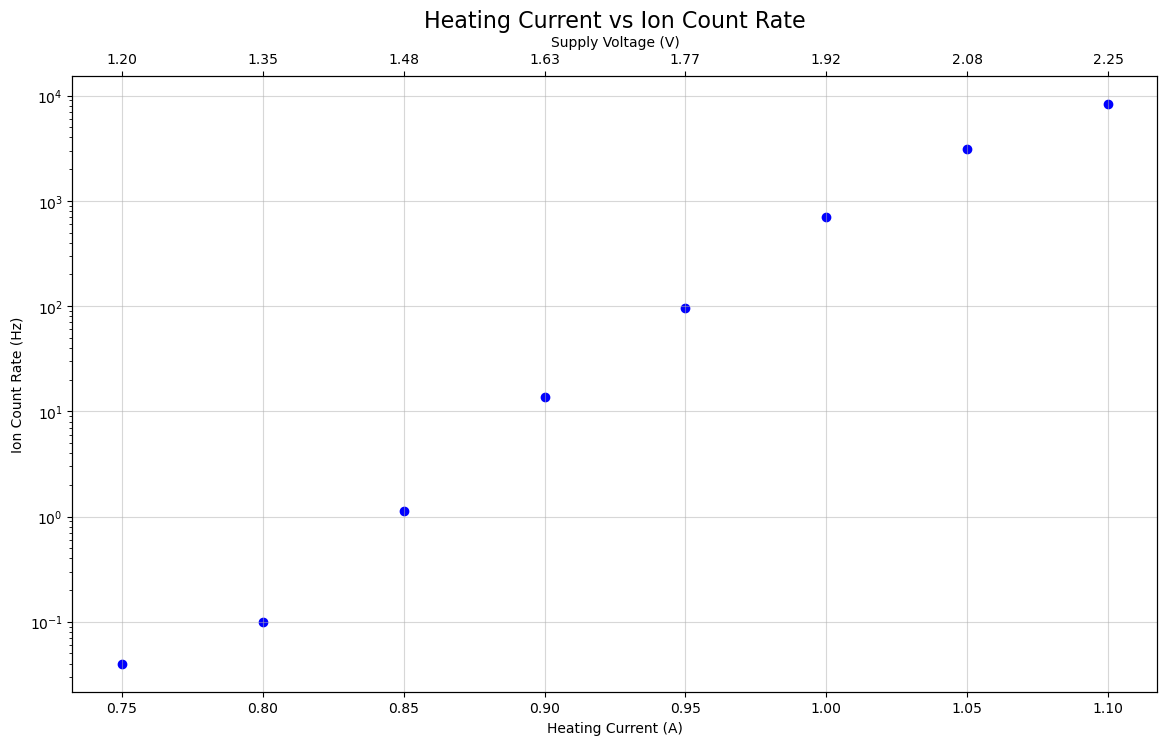

In [37]:
# Plot Current vs Count Rate
fig, ax = plt.subplots(figsize=(14, 8))
plt.scatter(current_pd["current_amps"], current_pd["rate_hz"], color='blue', label='Measured Rate')
plt.xlabel('Heating Current (A)')
plt.ylabel('Ion Count Rate (Hz)')
plt.yscale('log')
plt.title('Heating Current vs Ion Count Rate', fontsize = 16)
plt.grid(alpha = 0.5)

# Set twin x-axis with voltage values
ax2 = ax.twiny()
ax2.set_xlabel('Supply Voltage (V)')
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(current_pd["current_amps"])
ax2.set_xticklabels([f"{v:.2f}" for v in current_pd["Voltage_V"]])

plt.show()
